# 01. Análisis Exploratorio y Aprendizaje No Superficial

### Contexto de Negocio e Hipótesis
Este análisis busca identificar patrones intrínsecos en el rendimiento físico de los socios del gimnasio. 
**Hipótesis:** Las métricas biométricas (BPM) y de esfuerzo (Calorías, Duración) permiten segmentar naturalmente a los atletas sin necesidad de etiquetas previas, lo que optimiza la personalización de servicios y planes de entrenamiento.

In [8]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Añadimos la raíz para importar nuestros módulos y definimos rutas
sys.path.append('..')
from src.data_preprocessing import load_gym_data

# Configuración visual para gráficos más profesionales
sns.set_theme(style="whitegrid")
PLOTS_DIR = '../results/plots/'
os.makedirs(PLOTS_DIR, exist_ok=True)

In [9]:
# Cargar el dataset usando nuestra función modular
df = load_gym_data('../data/gym_members_exercise_tracking.csv')

In [10]:
#Verificar si hay datos nulos
print('Valores nulos por columna:')
df.isnull().sum()

Valores nulos por columna:


Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64

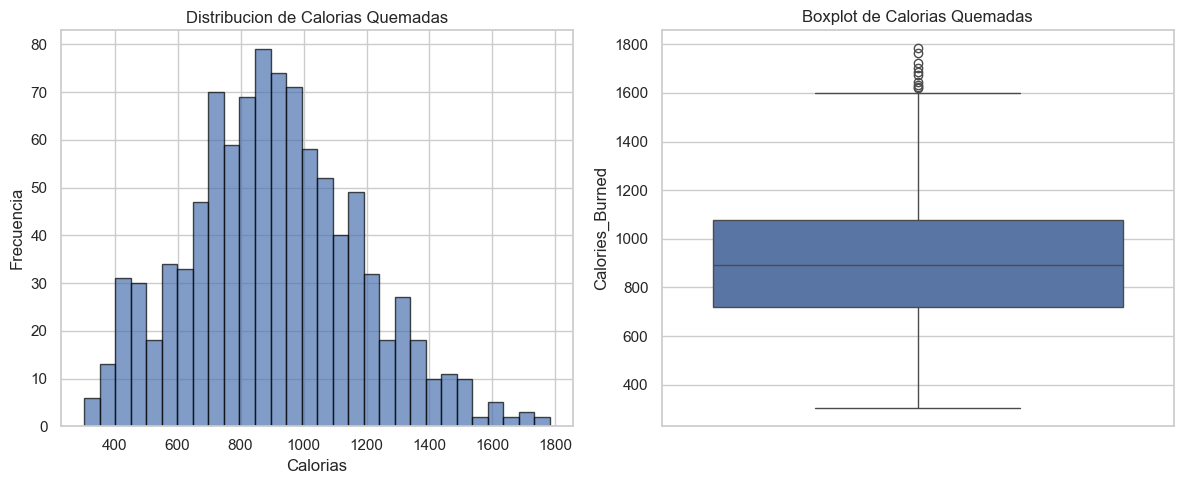

In [11]:
# Distribucion de variables objetivo (Calorias)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df['Calories_Burned'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribucion de Calorias Quemadas')
plt.xlabel('Calorias')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Calories_Burned'])
plt.title('Boxplot de Calorias Quemadas')
plt.tight_layout()
plt.show()

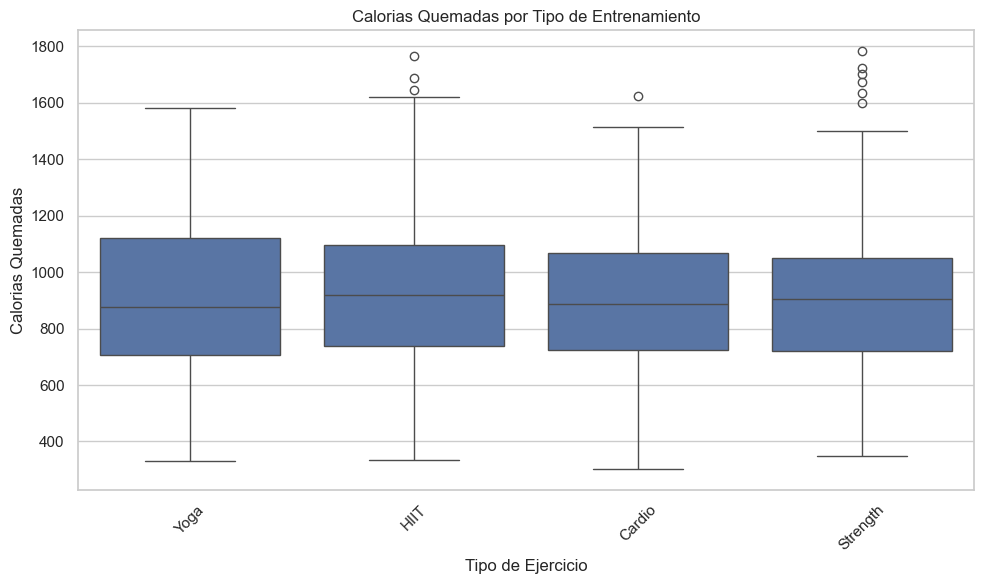

In [12]:
# Analisis por tipo de entrenamiento
plt.figure(figsize=(10, 6))
sns.boxplot(x='Workout_Type', y='Calories_Burned', data=df)
plt.xticks(rotation=45)
plt.title('Calorias Quemadas por Tipo de Entrenamiento')
plt.xlabel('Tipo de Ejercicio')
plt.ylabel('Calorias Quemadas')
plt.tight_layout()
plt.show()

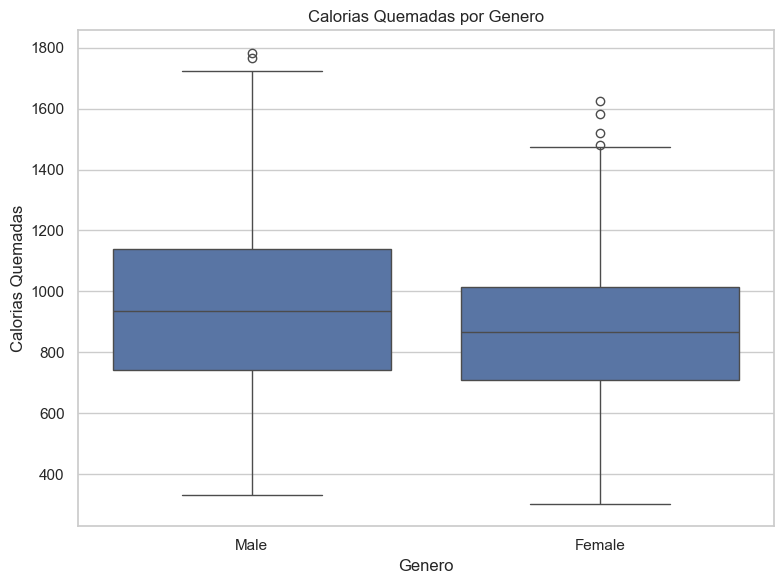

In [13]:
# Analisis por genero
plt.figure(figsize=(8, 6))
sns.boxplot(x='Gender', y='Calories_Burned', data=df)
plt.title('Calorias Quemadas por Genero')
plt.xlabel('Genero')
plt.ylabel('Calorias Quemadas')
plt.tight_layout()
plt.show()

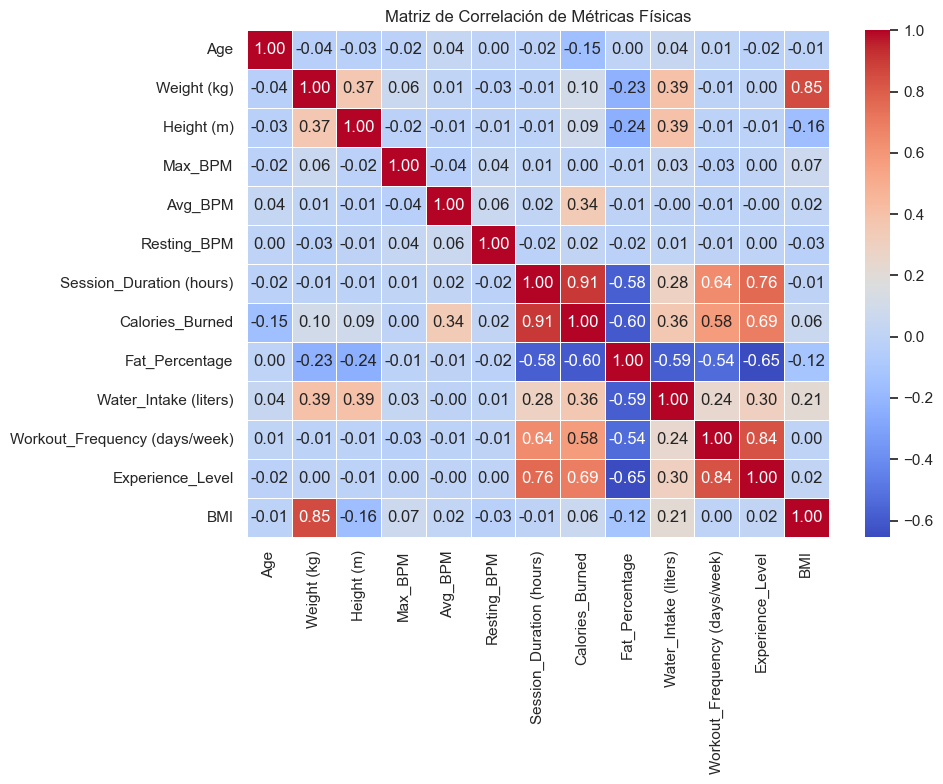

In [14]:
# Visualizar la matriz de correlación para entender las relaciones lineales
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Métricas Físicas')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '01_correlation_matrix.png'))
plt.show()

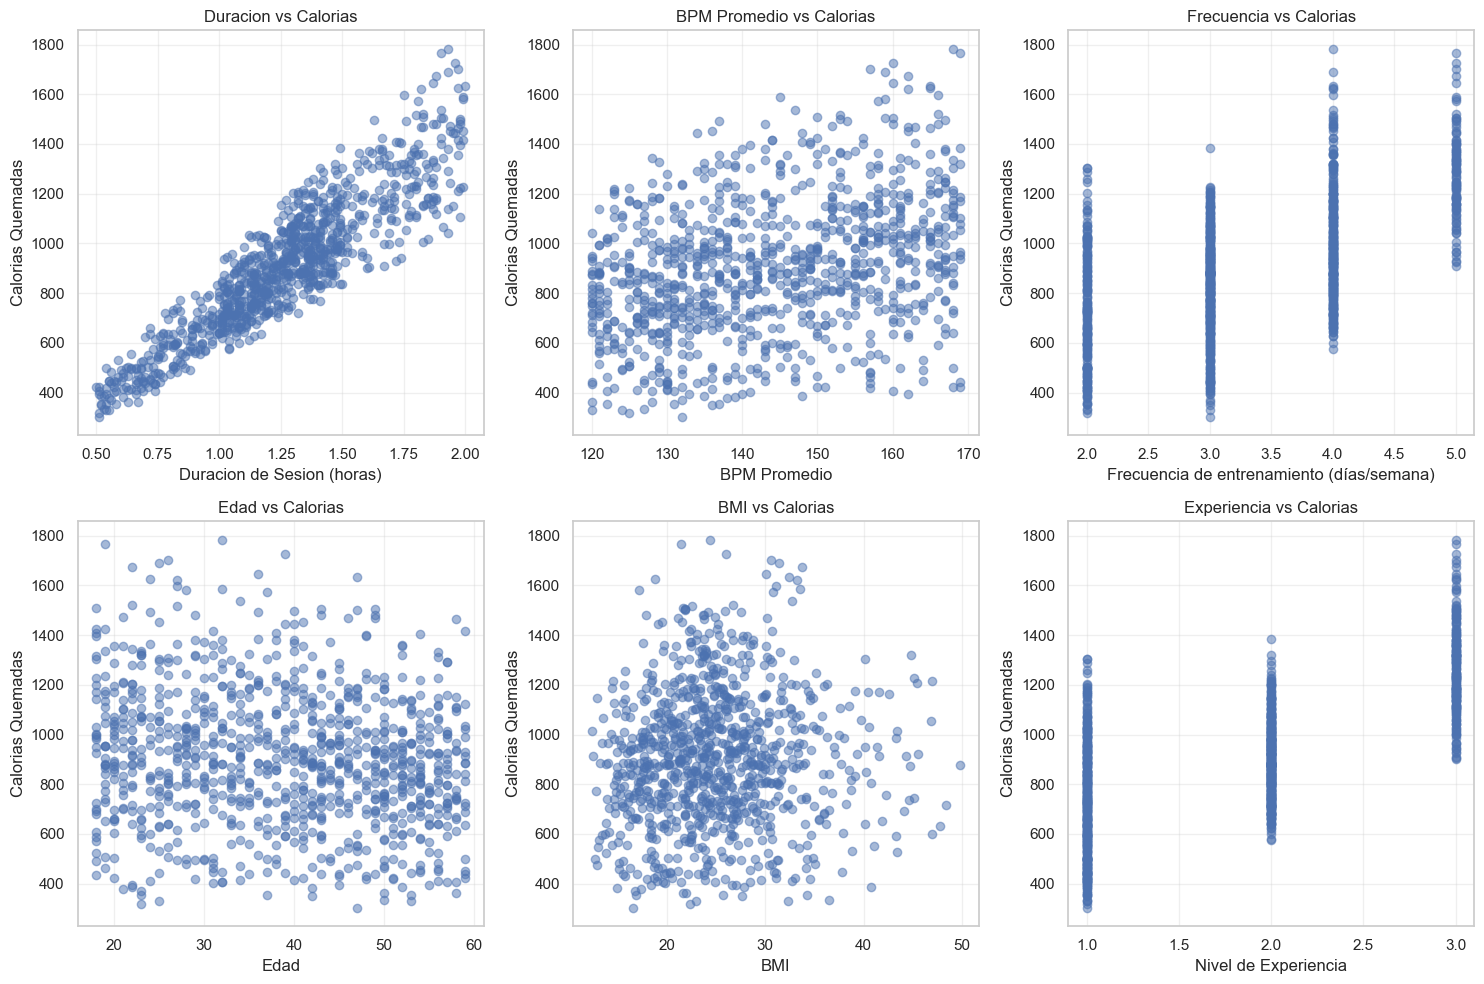

In [15]:
# Relacion entre variables clave
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Duracion de sesion vs Calorias
axes[0, 0].scatter(df['Session_Duration (hours)'], df['Calories_Burned'], alpha=0.5)
axes[0, 0].set_xlabel('Duracion de Sesion (horas)')
axes[0, 0].set_ylabel('Calorias Quemadas')
axes[0, 0].set_title('Duracion vs Calorias')
axes[0, 0].grid(True, alpha=0.3)

# BPM Promedio vs Calorias
axes[0, 1].scatter(df['Avg_BPM'], df['Calories_Burned'], alpha=0.5)
axes[0, 1].set_xlabel('BPM Promedio')
axes[0, 1].set_ylabel('Calorias Quemadas')
axes[0, 1].set_title('BPM Promedio vs Calorias')
axes[0, 1].grid(True, alpha=0.3)

# Frecuencia de entrenamiento vs Calorias
axes[0, 2].scatter(df['Workout_Frequency (days/week)'], df['Calories_Burned'], alpha=0.5)
axes[0, 2].set_xlabel('Frecuencia de entrenamiento (días/semana)')
axes[0, 2].set_ylabel('Calorias Quemadas')
axes[0, 2].set_title('Frecuencia vs Calorias')
axes[0, 2].grid(True, alpha=0.3)

# Edad vs Calorias
axes[1, 0].scatter(df['Age'], df['Calories_Burned'], alpha=0.5)
axes[1, 0].set_xlabel('Edad')
axes[1, 0].set_ylabel('Calorias Quemadas')
axes[1, 0].set_title('Edad vs Calorias')
axes[1, 0].grid(True, alpha=0.3)

# BMI vs Calorias
axes[1, 1].scatter(df['BMI'], df['Calories_Burned'], alpha=0.5)
axes[1, 1].set_xlabel('BMI')
axes[1, 1].set_ylabel('Calorias Quemadas')
axes[1, 1].set_title('BMI vs Calorias')
axes[1, 1].grid(True, alpha=0.3)

# Nivel de experiencia vs Calorias
axes[1, 2].scatter(df['Experience_Level'], df['Calories_Burned'], alpha=0.5)
axes[1, 2].set_xlabel('Nivel de Experiencia')
axes[1, 2].set_ylabel('Calorias Quemadas')
axes[1, 2].set_title('Experiencia vs Calorias')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# Deteccion de outliers con IQR
def detectar_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = data[(data[column] < limite_inferior) | (data[column] > limite_superior)]
    return len(outliers)

print("Outliers por variable:")
for col in ['Calories_Burned', 'Session_Duration (hours)', 'Avg_BPM', 'BMI', 'Age']:
    n_outliers = detectar_outliers_iqr(df, col)
    print(f"{col}: Hay {n_outliers} outliers ({n_outliers/len(df)*100:.2f}%)")

Outliers por variable:
Calories_Burned: Hay 10 outliers (1.03%)
Session_Duration (hours): Hay 0 outliers (0.00%)
Avg_BPM: Hay 0 outliers (0.00%)
BMI: Hay 25 outliers (2.57%)
Age: Hay 0 outliers (0.00%)


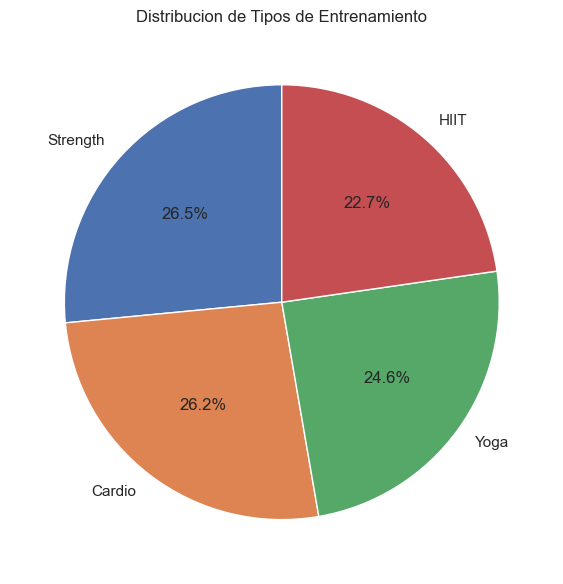

In [17]:
# Analisis de distribucion de Tipos de Ejercicio
plt.figure(figsize=(8, 6))
ejercicio_counts = df['Workout_Type'].value_counts()
plt.pie(ejercicio_counts.values, labels=ejercicio_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribucion de Tipos de Entrenamiento')
plt.tight_layout()
plt.show()

In [18]:
# Analisis de correlacion con calorias (solo caracteristicas mas relevantes)
corr_con_calorias = correlation_matrix['Calories_Burned'].sort_values(ascending=False)
print("\n=== CORRELACION CON CALORIAS QUEMADAS ===")
print(corr_con_calorias.round(3))


=== CORRELACION CON CALORIAS QUEMADAS ===
Calories_Burned                  1.000
Session_Duration (hours)         0.908
Experience_Level                 0.694
Workout_Frequency (days/week)    0.576
Water_Intake (liters)            0.357
Avg_BPM                          0.340
Weight (kg)                      0.095
Height (m)                       0.086
BMI                              0.060
Resting_BPM                      0.017
Max_BPM                          0.002
Age                             -0.155
Fat_Percentage                  -0.598
Name: Calories_Burned, dtype: float64


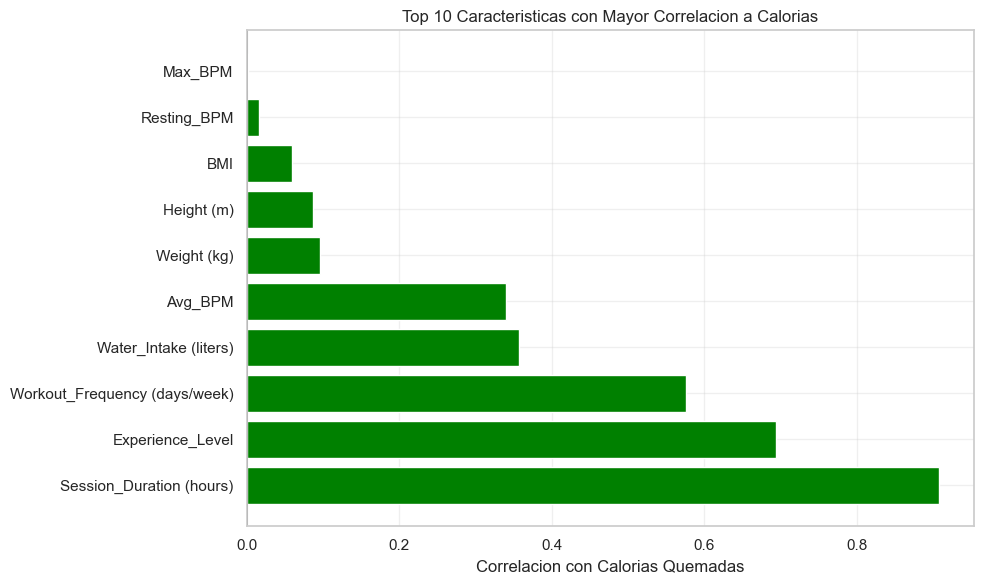

In [19]:
# Visualizacion de top correlaciones
plt.figure(figsize=(10, 6))
top_carcteristicas = corr_con_calorias[1:11]  # Excluir la propia calorías
colores = ['green' if x > 0 else 'red' for x in top_carcteristicas.values]
plt.barh(range(len(top_carcteristicas)), top_carcteristicas.values, color=colores)
plt.yticks(range(len(top_carcteristicas)), top_carcteristicas.index)
plt.xlabel('Correlacion con Calorias Quemadas')
plt.title('Top 10 Caracteristicas con Mayor Correlacion a Calorias')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Varianza explicada por PCA1: 0.49
Varianza explicada por PCA2: 0.26


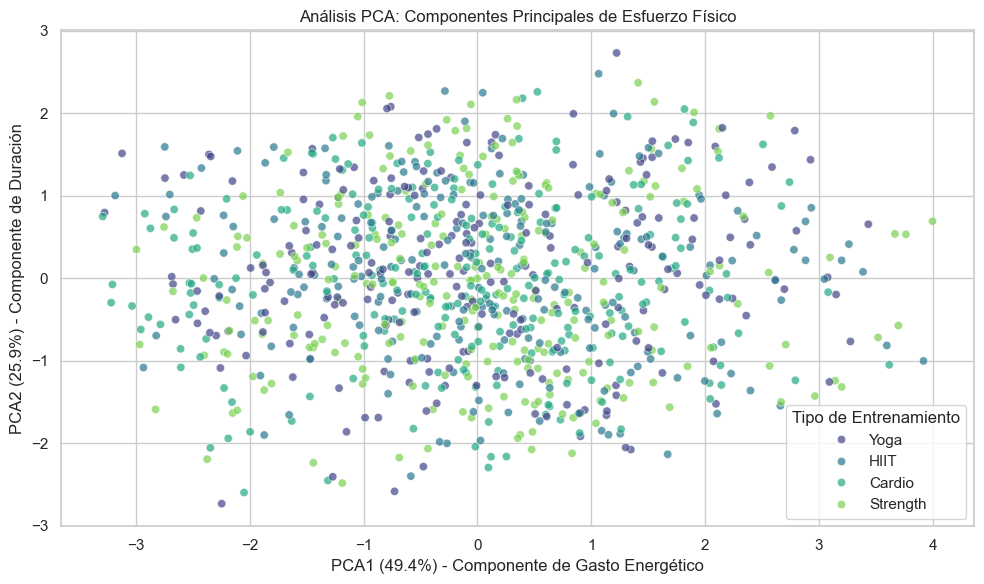

In [20]:
# Seleccionamos métricas de esfuerzo e intensidad
esfuerzo_cols = ['Max_BPM', 'Avg_BPM', 'Session_Duration (hours)', 'Calories_Burned']
X_esfuerzo = df[esfuerzo_cols]

# Escalamos los datos (vital para PCA y K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_esfuerzo)

# Aplicamos PCA para reducir a 2 componentes
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(X_scaled)

df['PCA1'] = pca_components[:, 0]
df['PCA2'] = pca_components[:, 1]

# Varianza explicada
var_exp = pca.explained_variance_ratio_
print(f"Varianza explicada por PCA1: {var_exp[0]:.2f}")
print(f"Varianza explicada por PCA2: {var_exp[1]:.2f}")

# Graficamos el resultado del PCA coloreando por tipo de entrenamiento
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Workout_Type', data=df, palette='viridis', alpha=0.7)
plt.title('Análisis PCA: Componentes Principales de Esfuerzo Físico')
plt.xlabel(f'PCA1 ({var_exp[0]*100:.1f}%) - Componente de Gasto Energético')
plt.ylabel(f'PCA2 ({var_exp[1]*100:.1f}%) - Componente de Duración')
plt.legend(title='Tipo de Entrenamiento')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '02_pca_esfuerzo.png'))
plt.show()

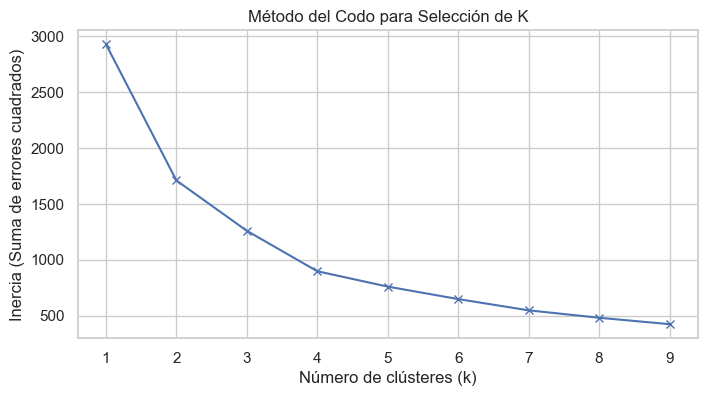

In [ ]:
# Justificación del número de clústeres (K)
inertia = []
K_range = range(1, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(pca_components)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Número de clústeres (k)')
plt.ylabel('Inercia (Suma de errores cuadrados)')
plt.title('Método del Codo para Selección de K')
plt.show()

Se selecciona **$K=3$** basándose en el Método del Codo, donde se observa el punto de inflexión significativo. Esto garantiza una segmentación con rigor técnico, evitando la arbitrariedad en la elección de grupos y asegurando que los perfiles (ej. Principiante, Intermedio, Avanzado) estén bien diferenciados estadísticamente.

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


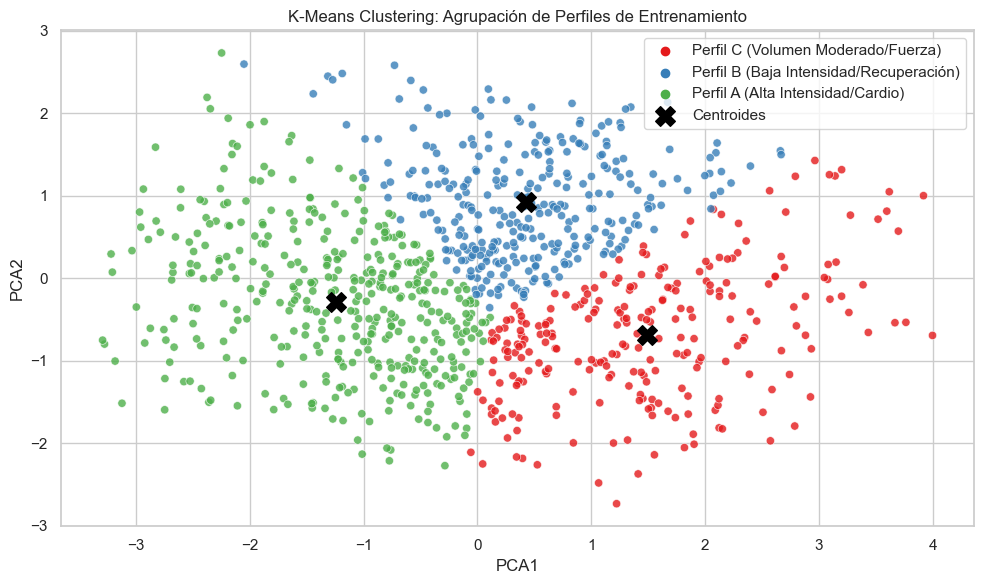

,Max_BPM,Avg_BPM,Session_Duration (hours),Calories_Burned
Cluster_Name,,,,
Perfil A (Alta Intensidad/Cardio),182.29,136.40,0.99,670.23
Perfil B (Baja Intensidad/Recuperación),172.04,153.90,1.29,980.80
Perfil C (Volumen Moderado/Fuerza),185.80,143.09,1.65,1195.52


In [6]:
# Entrenamos K-Means sobre las componentes del PCA
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(pca_components)

# Etiquetas descriptivas basadas en la intuición de los datos
cluster_labels = {
    0: 'Perfil A (Alta Intensidad/Cardio)',
    1: 'Perfil B (Baja Intensidad/Recuperación)',
    2: 'Perfil C (Volumen Moderado/Fuerza)'
}
df['Cluster_Name'] = df['Cluster'].map(cluster_labels)

# Visualización de los Clústeres
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster_Name', data=df, palette='Set1', alpha=0.8)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            s=200, c='black', marker='X', label='Centroides')

plt.title('K-Means Clustering: Agrupación de Perfiles de Entrenamiento')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '03_kmeans_clusters.png'))
plt.show()

# Resumen de los clústeres para argumentar en la presentación
cluster_summary = df.groupby('Cluster_Name')[esfuerzo_cols].mean().round(2)
display(cluster_summary)

=== Análisis No Supervisado: Clustering de Miembros ===


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


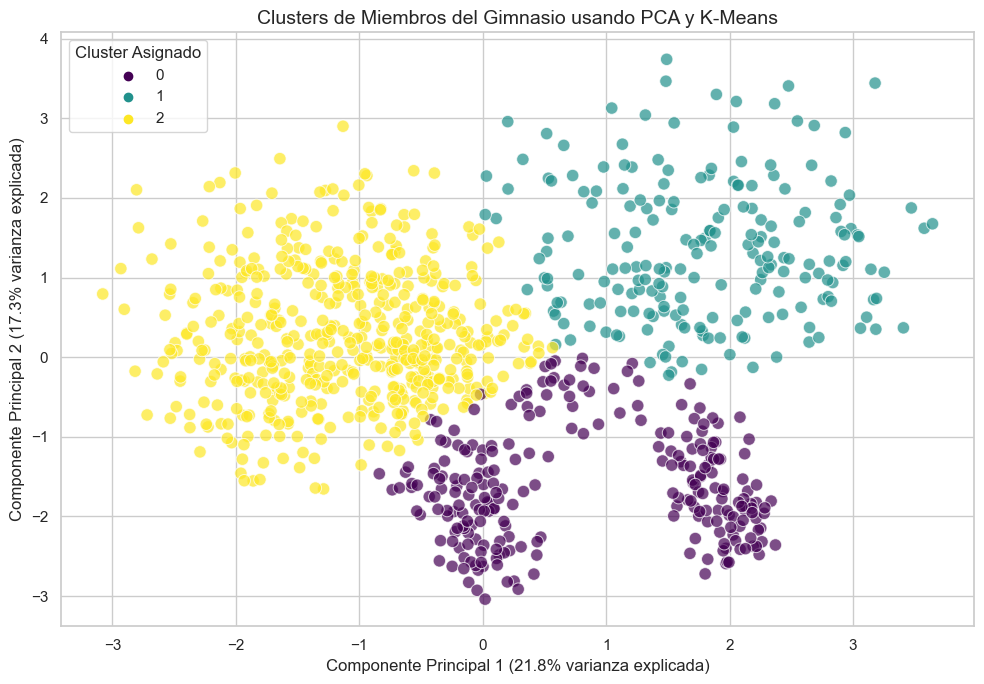

Justificación: Se utilizó KMeans para encontrar agrupamientos naturales en los usuarios (ej. alta intensidad vs baja intensidad).
Dado que tenemos más de 10 variables, usamos PCA para reducir la dimensionalidad a 2 componentes principales y poder visualizar las fronteras de los clusters de manera efectiva.


In [5]:
print("=== Análisis No Supervisado: Clustering de Miembros ===")

# 1. Seleccionamos solo las variables numéricas y escalamos (KMeans es sensible a la escala)
numeric_cols = ['Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 
                'Resting_BPM', 'Session_Duration (hours)', 'Water_Intake (liters)', 
                'Workout_Frequency (days/week)', 'BMI']
X_num = df[numeric_cols].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

# 2. Aplicamos KMeans para encontrar 3 grupos (clusters) de usuarios
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df_clusters = X_num.copy()
df_clusters['Cluster'] = clusters

# 3. Aplicamos PCA para reducir de 10 dimensiones a 2 y poder graficar
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# 4. Visualización Avanzada
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='viridis', s=80, alpha=0.7)

# Etiquetas con la varianza explicada por cada componente
var_expl = pca.explained_variance_ratio_ * 100
plt.title('Clusters de Miembros del Gimnasio usando PCA y K-Means', fontsize=14)
plt.xlabel(f'Componente Principal 1 ({var_expl[0]:.1f}% varianza explicada)')
plt.ylabel(f'Componente Principal 2 ({var_expl[1]:.1f}% varianza explicada)')
plt.legend(title='Cluster Asignado', loc='best')
plt.tight_layout()

# Guardar y mostrar
plt.savefig(os.path.join(PLOTS_DIR, '02_pca_kmeans_clusters.png'))
plt.show()

print("Justificación: Se utilizó KMeans para encontrar agrupamientos naturales en los usuarios (ej. alta intensidad vs baja intensidad).")
print("Dado que tenemos más de 10 variables, usamos PCA para reducir la dimensionalidad a 2 componentes principales y poder visualizar las fronteras de los clusters de manera efectiva.")

In [19]:
# Resumen ejecutivo del analisis
print("\n" + "="*33)
print("RESUMEN DEL ANALISIS EXPLORATORIO")
print("="*33)
print(f"• Total de registros: {len(df)}")
print(f"• Total de variables: {len(df.columns)}")
print(f"• Variables numericas: {len(numeric_cols)}")
print(f"• Variables categoricas: {df.select_dtypes(include=['object']).columns.tolist()}")
print(f"• Rango de calorias: {df['Calories_Burned'].min():.0f} - {df['Calories_Burned'].max():.0f}")
print(f"• Media de calorias: {df['Calories_Burned'].mean():.0f} ± {df['Calories_Burned'].std():.0f}")
print(f"• Correlacion mas fuerte con calorias: {corr_con_calorias.index[1]} "f"(r = {corr_con_calorias.iloc[1]:.3f})")
print(f"• Tipo de entrenamiento mas comun: {df['Workout_Type'].mode().iloc[0]}")
print(f"• Genero mas frecuente: {df['Gender'].mode().iloc[0]}")
print(f"• Porcentaje de datos sin valores nulos: {(1 - df.isnull().sum().sum()/(len(df)*len(df.columns)))*100:.1f}%")


RESUMEN DEL ANALISIS EXPLORATORIO
• Total de registros: 973
• Total de variables: 15
• Variables numericas: 13
• Variables categoricas: ['Gender', 'Workout_Type']
• Rango de calorias: 303 - 1783
• Media de calorias: 905 ± 273
• Correlacion mas fuerte con calorias: Session_Duration (hours) (r = 0.908)
• Tipo de entrenamiento mas comun: Strength
• Genero mas frecuente: Male
• Porcentaje de datos sin valores nulos: 100.0%


In [20]:
# Perspectivas adicionales
print("\n" + "="*31)
print("PERSPECTIVAS CLAVE DEL ANALISIS")
print("="*31)
print("""
1. Las variables mas correlacionadas con calorias quemadas son:
   - Session_Duration (horas): correlacion fuerte positiva
   - Avg_BPM: correlacion moderada positiva
   - Workout_Frequency: correlacion positiva

2. Los tipos de entrenamiento con mayor quema de calorias promedio:
   - HIIT y Cardio generan mayor gasto calorico
   - Yoga y Strength tienen menor promedio

3. Segmentacion natural:
   - Existe variabilidad significativa por genero y edad
   - Los usuarios con mayor experiencia queman mas calorias

4. Outliers detectados:
   - Algunos usuarios tienen valores extremos en duracion de sesion
   - Calorias quemadas muestran distribucion asimetrica

5. Recomendaciones iniciales:
   - Enfocar modelos en duracion y BPM como caracteristicas principales
   - Considerar interacciones entre tipo de entrenamiento y otras variables
   - Evaluar transformaciones para manejar asimetria
""")


PERSPECTIVAS CLAVE DEL ANALISIS

1. Las variables mas correlacionadas con calorias quemadas son:
   - Session_Duration (horas): correlacion fuerte positiva
   - Avg_BPM: correlacion moderada positiva
   - Workout_Frequency: correlacion positiva

2. Los tipos de entrenamiento con mayor quema de calorias promedio:
   - HIIT y Cardio generan mayor gasto calorico
   - Yoga y Strength tienen menor promedio

3. Segmentacion natural:
   - Existe variabilidad significativa por genero y edad
   - Los usuarios con mayor experiencia queman mas calorias

4. Outliers detectados:
   - Algunos usuarios tienen valores extremos en duracion de sesion
   - Calorias quemadas muestran distribucion asimetrica

5. Recomendaciones iniciales:
   - Enfocar modelos en duracion y BPM como caracteristicas principales
   - Considerar interacciones entre tipo de entrenamiento y otras variables
   - Evaluar transformaciones para manejar asimetria

